In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

# Ajout du chemin vers les sources HELIOS
sys.path.insert(0, os.path.abspath('src'))

import helios
from helios.core.context import Layer

# Configuration de l'affichage
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'inferno'

d:\HELIOS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Étape 1 : La Scène Astrophysique

Nous définissons notre système cible :
- Une **Étoile** brillante au centre (type Soleil).
- Une **Planète** beaucoup moins lumineuse située à 1 UA (Unité Astronomique).

Pour cette démonstration, nous exagérons le flux de la planète pour qu'elle soit visible sans traitement extrême, mais le principe reste le même.

Scène configurée à 10.0 pc


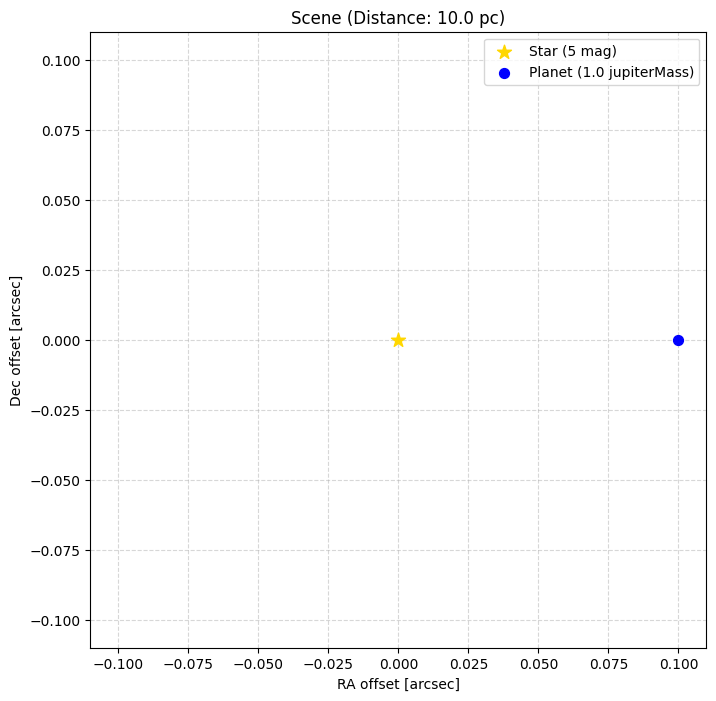

In [2]:
# Création de la scène
scene = helios.Scene(distance=10*u.pc, name="Système Cible")

# Ajout de l'étoile (au centre)
star = helios.Star(temperature=5778*u.K, magnitude=5, position=(0, 0))
scene.add(star)

# Ajout de la planète (à 0.1 seconde d'arc, soit 1 UA à 10 pc)
# Nous utilisons un albedo élevé et un rayon artificiel pour la visibilité de la démo
planet = helios.Planet(mass=1*u.M_jup, position=(0.1*u.arcsec, 0*u.arcsec), albedo=1.0)
# Hack pour la démo : on force la planète à être plus brillante
planet.magnitude = 10 
scene.add(planet)

print(f"Scène configurée à {scene.distance}")
scene.plot()
plt.show()

## Étape 2 : L'Interféromètre (Pupille)

Nous construisons un interféromètre simple composé de deux télescopes séparés par une ligne de base $B$.
- Diamètre des télescopes : 2 m
- Ligne de base ($B$) : 10 m

La configuration de la pupille définit comment la lumière est collectée.

Interféromètre : 2 télescopes, Base = 10.0 m


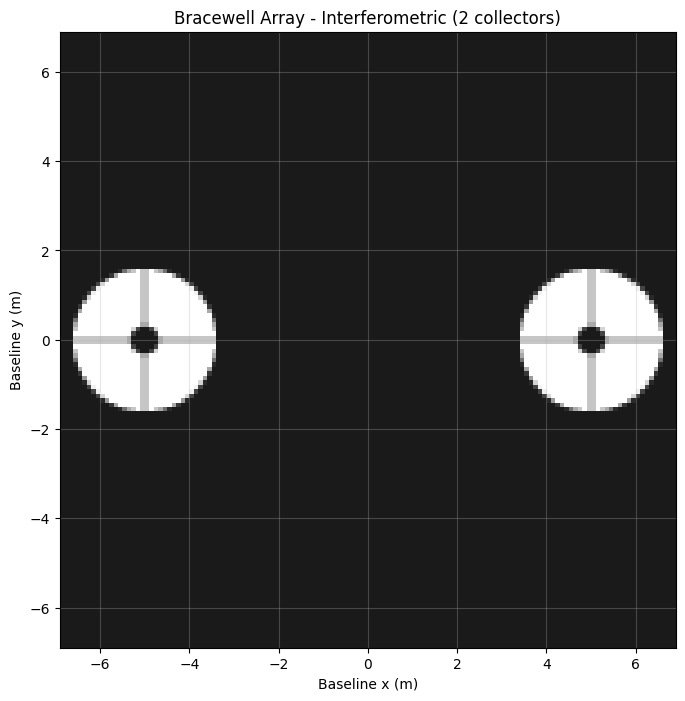

In [3]:
# Configuration de l'interféromètre
B = 10 * u.m  # Ligne de base
D = 1 * u.m   # Diamètre des télescopes

pupil = helios.Pupil(diameter=D)
pupil.add_disk(center=(0,0), radius=D/2)
pupil.add_spiders(arms=4, width=0.01*D)
pupil.add_central_obscuration(diameter=0.2*D)

interferometer = helios.TelescopeArray(name="Bracewell Array")
interferometer.add_collector(pupil, position=(-B/2, 0), size=D) # Télescope Gauche
interferometer.add_collector(pupil, position=(B/2, 0), size=D)  # Télescope Droit

print(f"Interféromètre : {len(interferometer.collectors)} télescopes, Base = {B}")

# Visualisation de la pupille
interferometer.plot_array()
plt.show()

## Étape 3 : Le Front d'Onde (Avant Nulling)

Observons le front d'onde (l'amplitude et la phase de la lumière) après avoir traversé les télescopes, mais avant toute combinaison.
- **Amplitude** : On voit les deux disques lumineux correspondant aux télescopes.
- **Phase** : Elle est uniforme (0 partout) car nous n'avons pas encore introduit de perturbations ou de déphasage.

<class 'helios.core.simulation.WavefrontArray'>


Plotting sources: 100%|██████████| 2/2 [00:00<00:00,  4.95src/s]


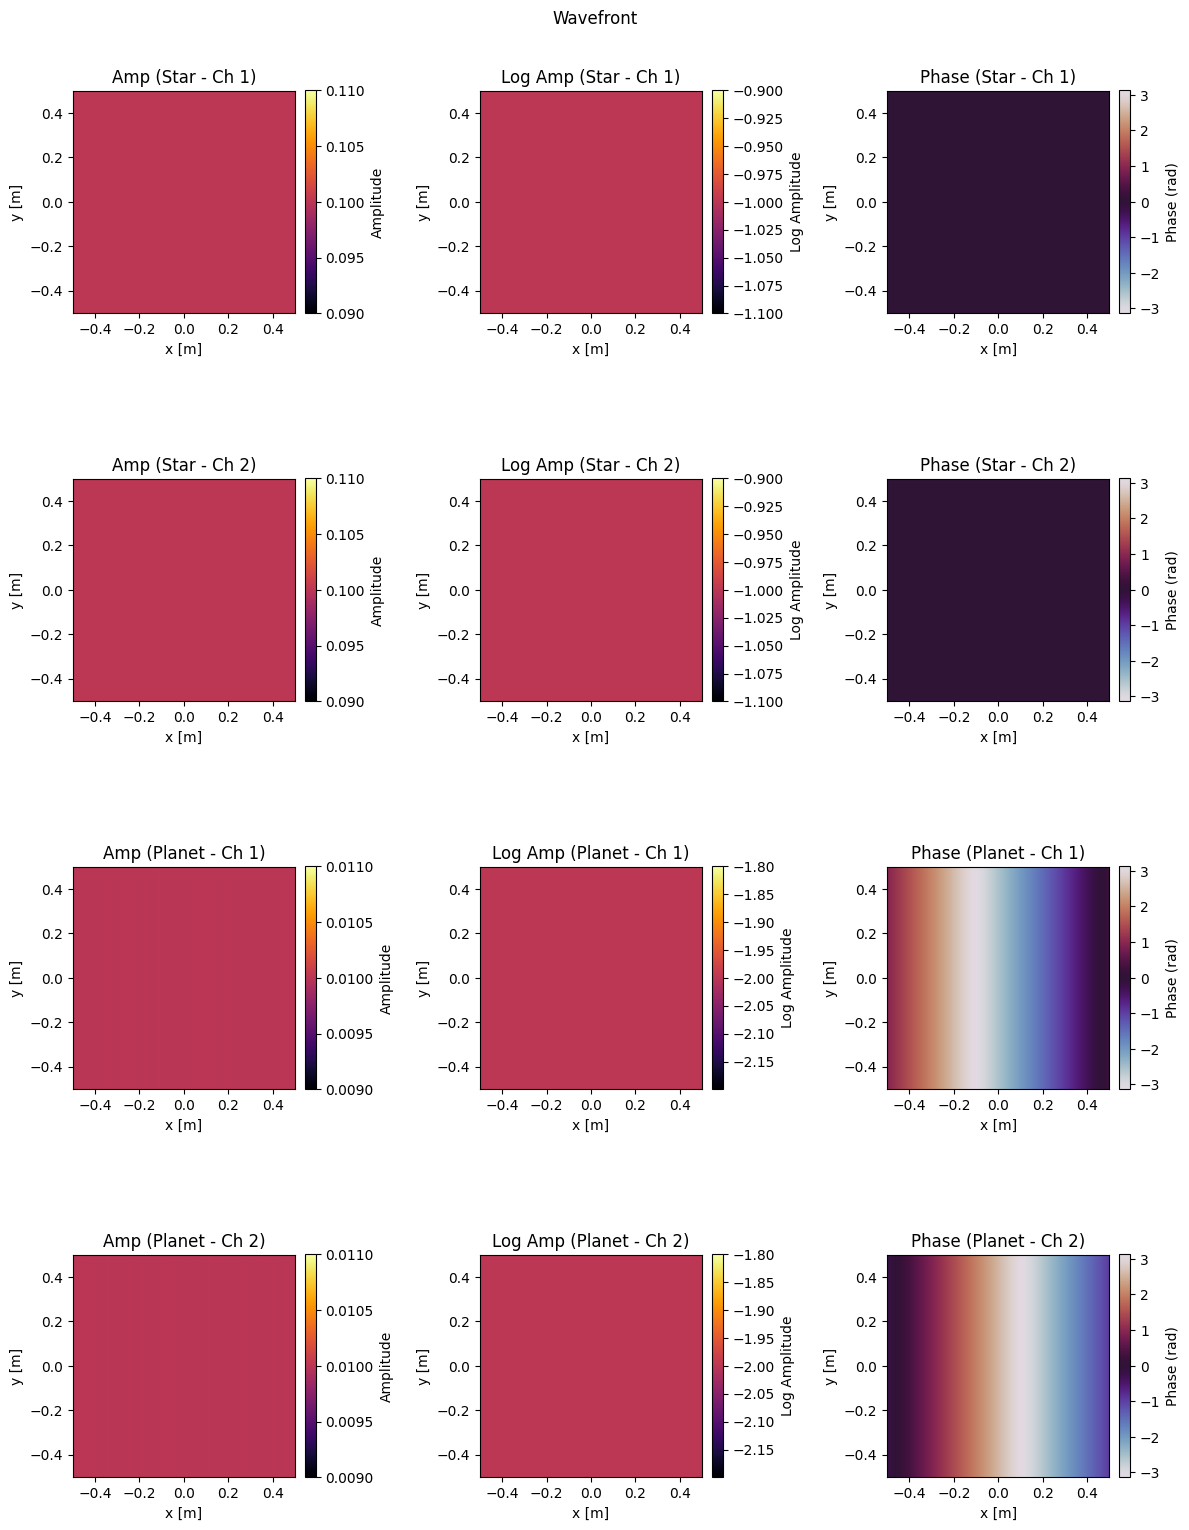

In [4]:
# Génération du front d'onde initial depuis la scène
# Nous utilisons un Context pour gérer les paramètres de simulation
ctx = helios.Context(wavelength=550*u.nm, npix=512)
ctx.add_layer(scene)
ctx.add_layer(interferometer)

# get_input_wavefront() génère le front d'onde en tenant compte de la scène et de l'atmosphère (si présente)
# Par défaut, coherent_sources=True, ce qui crée un échantillon par source (Étoile, Planète)
wf_scene = ctx.get_input_wavefront(coherent_sources=True) 

print(type(wf_scene))

# On utilise stack_method=np.sum pour visualiser la somme des intensités des sources
wf_scene.plot(title=f"Wavefront")
plt.show()

<class 'helios.core.simulation.WavefrontArray'>


Plotting sources: 100%|██████████| 2/2 [00:00<00:00,  6.02src/s]


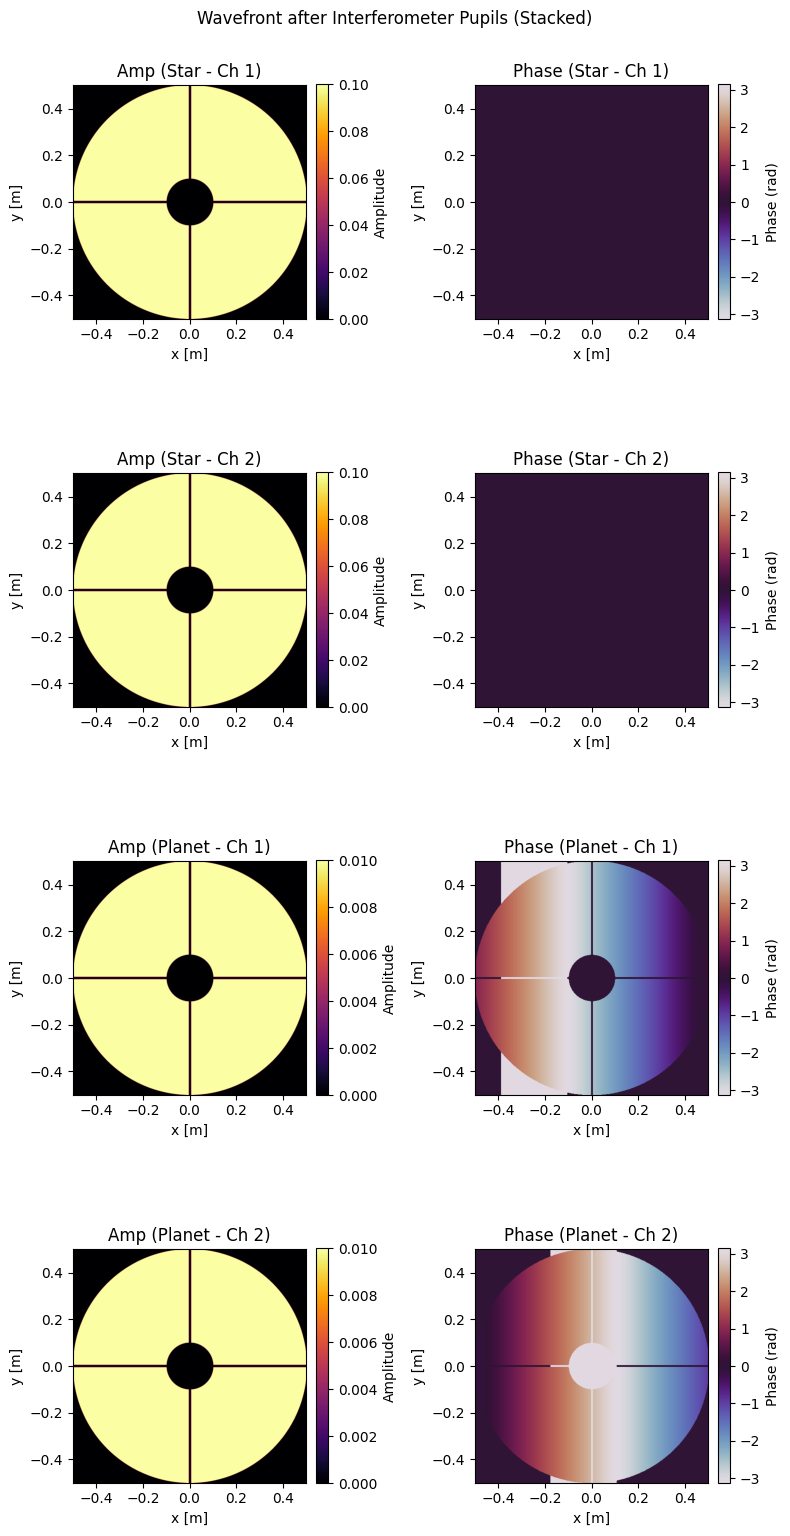

In [5]:
# Passage à travers les pupilles
wf_pupil = interferometer.process(wf_scene, ctx)
print(type(wf_pupil))
# Visualisation empilée
wf_pupil.plot(title="Wavefront after Interferometer Pupils (Stacked)", log_scale=False)
plt.show()

Plotting sources: 100%|██████████| 2/2 [00:00<00:00, 10.26src/s]


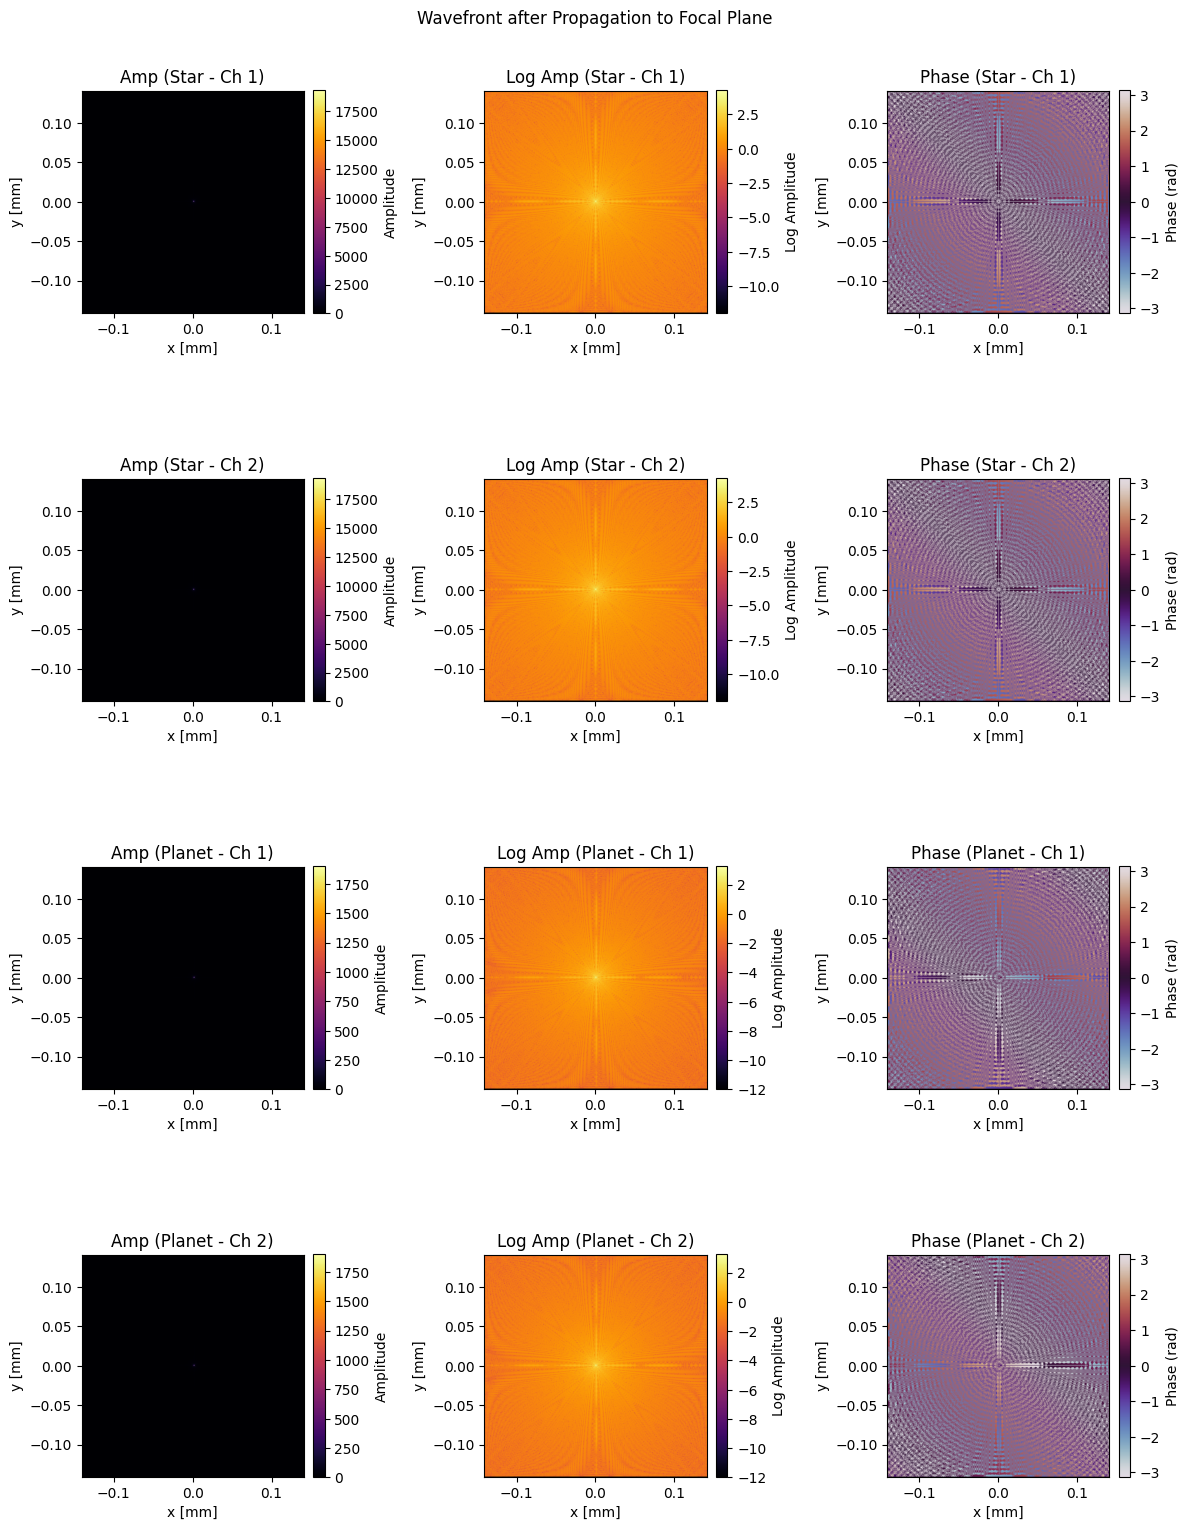

In [6]:
wf = wf_pupil.propagate()
wf.plot(title="Wavefront after Propagation to Focal Plane")
plt.show()

## Étape 4 : Le "Nuller" (Déphasage de $\pi$)

C'est ici que la magie de Bracewell opère. Nous introduisons artificiellement un déphasage de $\pi$ (180°) sur l'un des deux télescopes.
- Cela inverse le signe du champ électrique sur une moitié de la pupille.
- L'étoile, étant sur l'axe, verra ses contributions s'annuler (interférences destructives).

Plotting channels (stacked): 100%|██████████| 2/2 [00:00<00:00,  9.95ch/s]


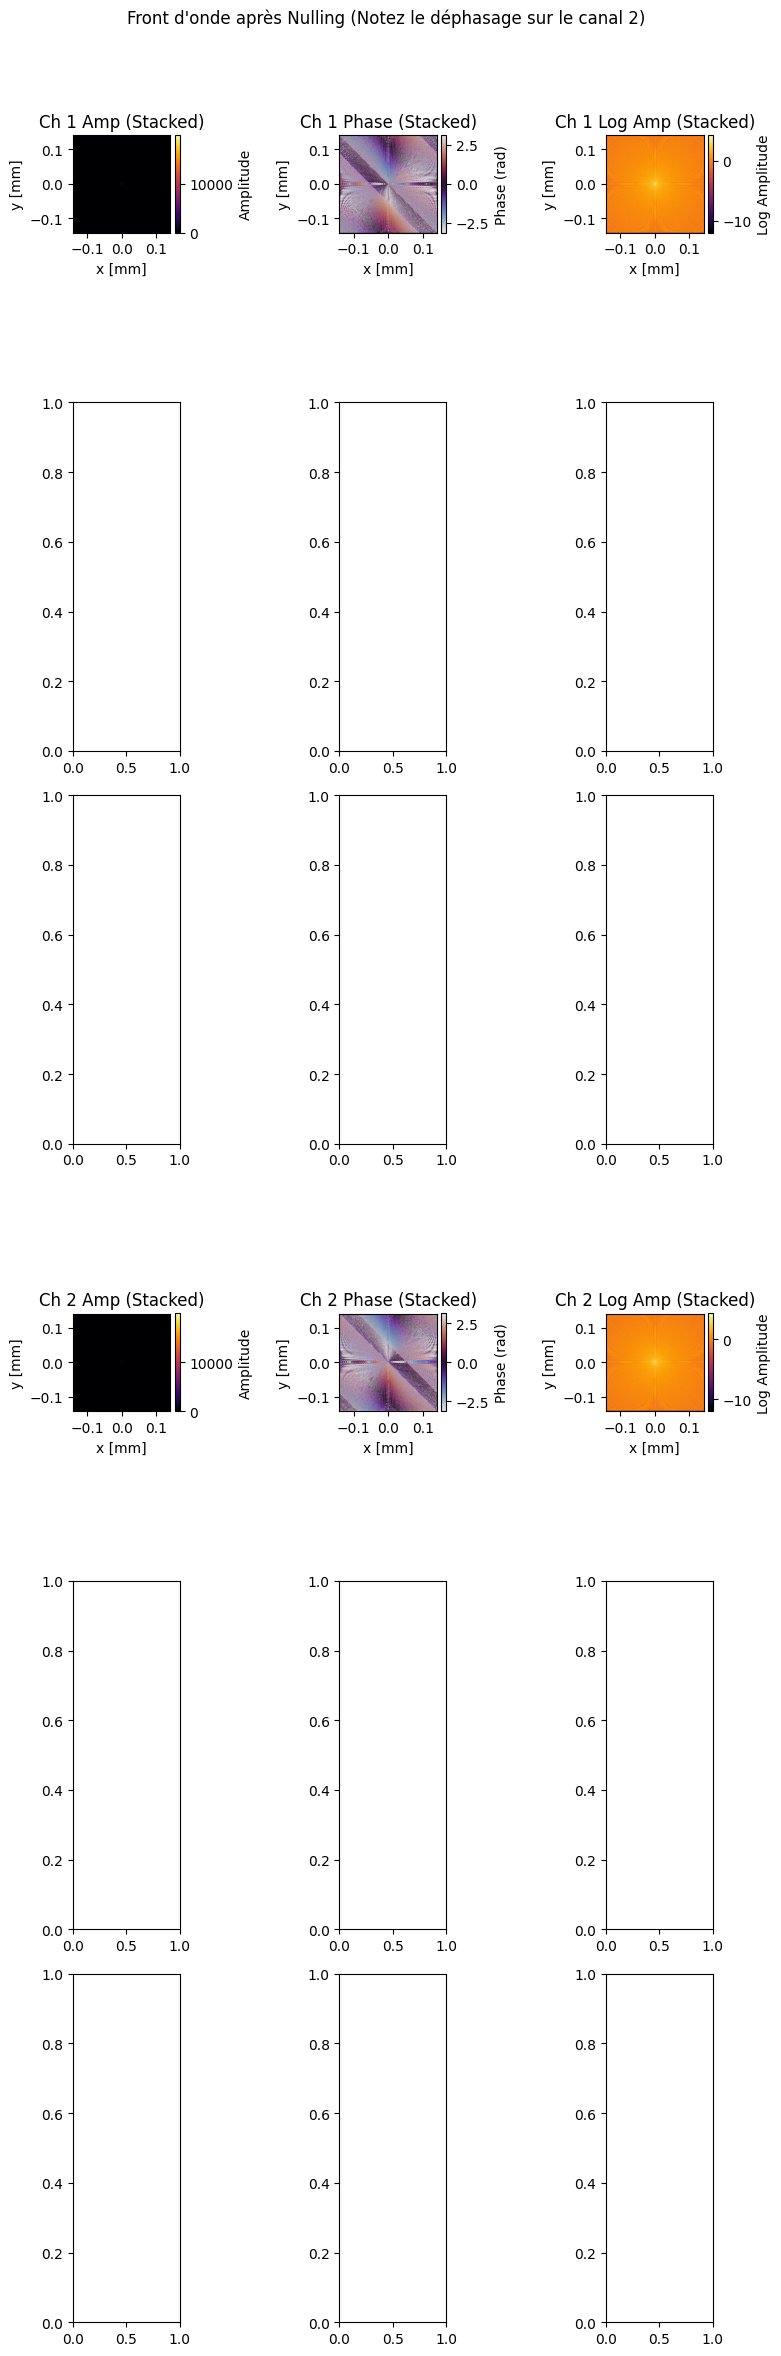

In [7]:
class BracewellPhaseShifter(Layer):
    """Composant personnalisé pour appliquer un déphasage de Pi sur un des bras."""
    def process(self, wavefront, context):
        # On copie pour ne pas modifier l'original
        wf = wavefront.copy()
        
        # Check for WavefrontArray (handle both direct import and package access)
        is_array = False
        if hasattr(helios, 'WavefrontArray') and isinstance(wf, helios.WavefrontArray):
            is_array = True
        elif hasattr(helios.core.simulation, 'WavefrontArray') and isinstance(wf, helios.core.simulation.WavefrontArray):
            is_array = True
            
        if is_array:
            # Cas WavefrontArray : on déphase le deuxième télescope
            if len(wf) > 1:
                wf[1].field *= np.exp(1j * np.pi)
        else:
            # Cas Wavefront unique (Legacy) : moitié droite
            # Gestion du champ 3D (samples, size, size) ou 2D (size, size)
            if wf.field.ndim == 3:
                samples, h, w = wf.field.shape
                wf.field[:, :, w//2:] *= np.exp(1j * np.pi)
            else:
                h, w = wf.field.shape
                wf.field[:, w//2:] *= np.exp(1j * np.pi)
            
        return wf

nuller = BracewellPhaseShifter(name="Pi Shifter")
wf_nulled = nuller.process(wf, ctx)

# Visualisation après le Nuller
is_array_viz = False
if hasattr(helios, 'WavefrontArray') and isinstance(wf_nulled, helios.WavefrontArray):
    is_array_viz = True
elif hasattr(helios.core.simulation, 'WavefrontArray') and isinstance(wf_nulled, helios.core.simulation.WavefrontArray):
    is_array_viz = True

if is_array_viz:
    wf_nulled.plot(title="Front d'onde après Nulling (Notez le déphasage sur le canal 2)", stack_method=np.sum)
else:
    # Pour Wavefront unique, on utilise plot avec stack_method
    wf_nulled.plot(title="Front d'onde après Nulling (Stacked)", stack_method=np.sum)
    plt.show()

## Étape 5 : Détection (Plan Focal)

Enfin, nous focalisons la lumière sur un détecteur (caméra). C'est l'équivalent de faire la transformée de Fourier du champ dans la pupille.

**Résultat attendu :**
- Au centre de l'image (où se trouve l'étoile), nous devrions voir une zone sombre ("null") due aux interférences destructives.
- La planète, située légèrement hors axe, ne subit pas exactement le même déphasage géométrique et devrait apparaître (ou du moins, ne pas être totalement éteinte).

*Note : Les franges d'interférence sont visibles. L'étoile est "éteinte" au centre des franges.*

Plotting sources: 100%|██████████| 2/2 [00:00<00:00,  5.25src/s]


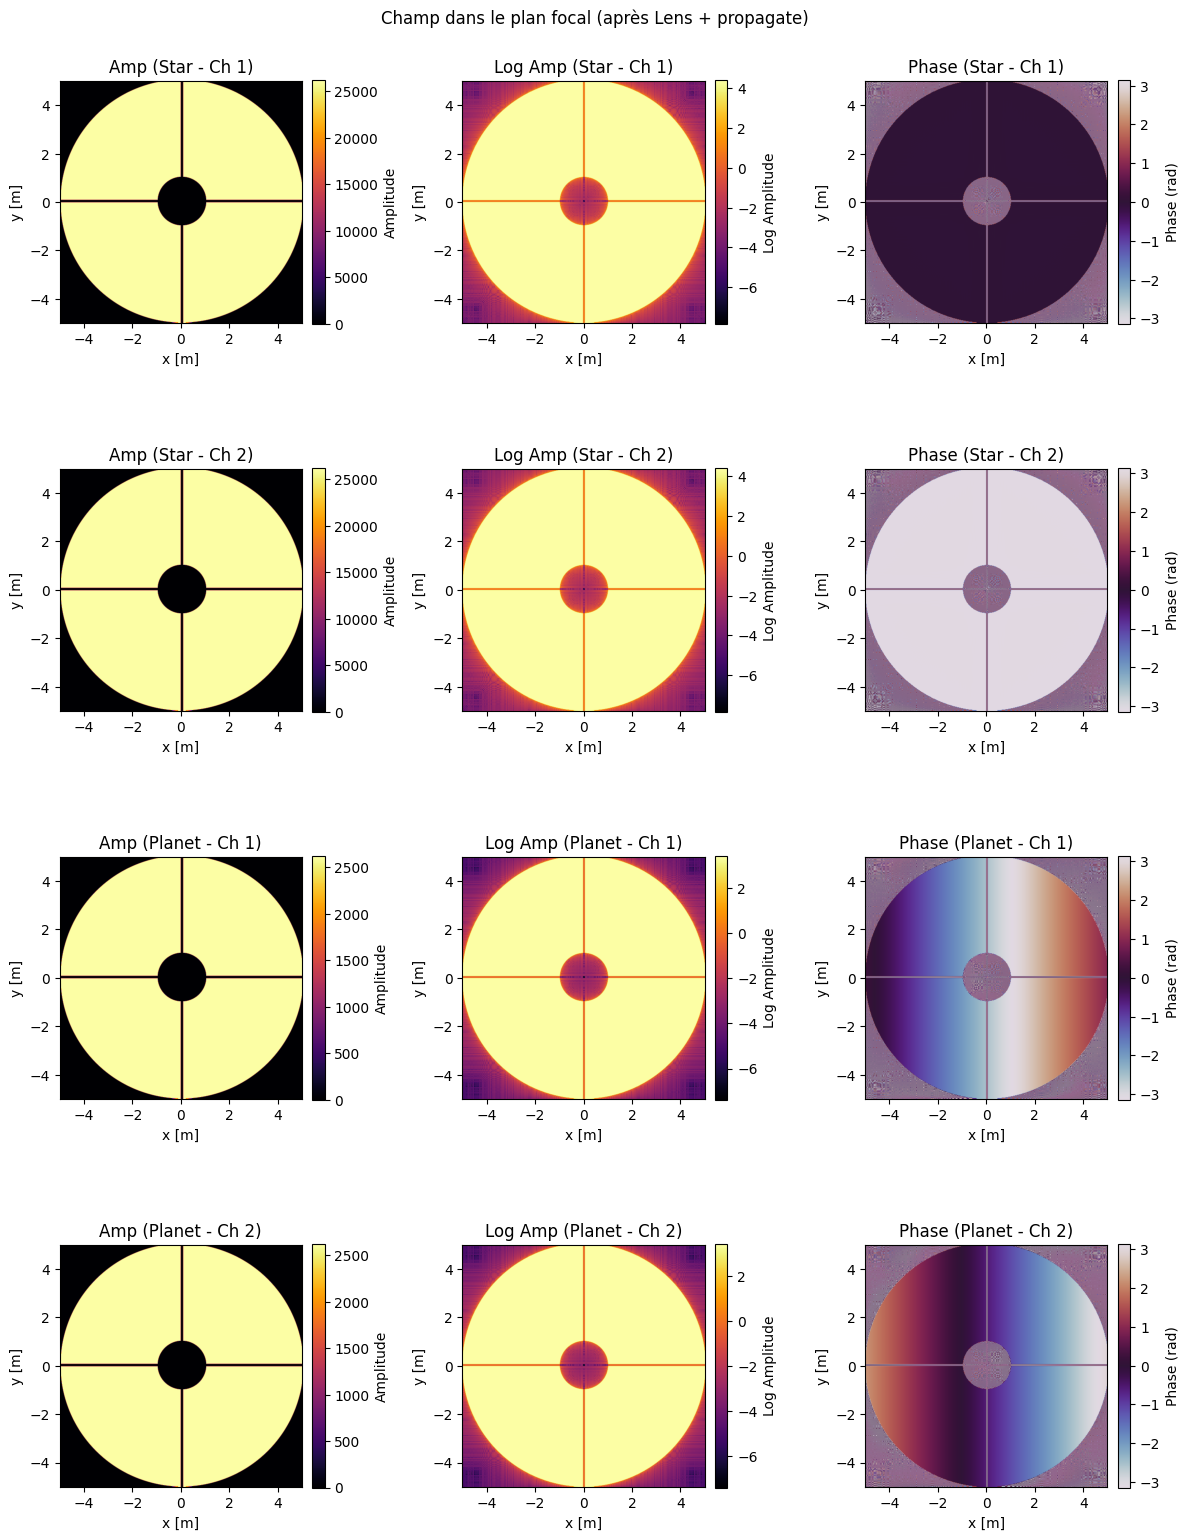

In [8]:
# Application d'une lentille mince et propagation
lens = helios.Lens(focal_length=10*u.m)

# On applique la lentille sur le front d'onde nulled (après Bracewell)
wf_after_lens = lens.process(wf_nulled, ctx)

# Propagation vers le plan focal en utilisant la focale mémorisée
# Utilise directement WavefrontArray.propagate(None) si nécessaire
wf_propagated = wf_after_lens.copy().propagate(None)

# Visualisation du module du champ dans le plan focal
if hasattr(helios, 'WavefrontArray') and isinstance(wf_propagated, helios.WavefrontArray):
    # Affiche chaque canal (utile pour inspection)
    wf_propagated.plot(title="Champ dans le plan focal (après Lens + propagate)")
else:
    plt.figure(figsize=(8, 6))
    amp = np.abs(wf_propagated.field)
    plt.imshow(np.log10(amp + 1e-12), origin='lower', cmap='inferno')
    plt.title("Champ (log amplitude) après Lens + propagate(None)")
    plt.colorbar(label="log |E|")
    plt.show()

## Étape 4 bis : Lentille et Propagation

Nous insérons une **lentille mince** pour modéliser la focalisation, puis nous utilisons `Wavefront.propagate(None)`.

- Si `distance=None`, la propagation utilise la **focale mémorisée** par la lentille.
- Si aucune focale n’est connue, le front d’onde reste inchangé et un `RuntimeWarning` est émis.

On visualise ensuite le champ propagé (plan focal) pour inspection rapide.

C:\Users\vince\AppData\Local\Temp\ipykernel_23668\3869444480.py:8: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(image + 1e-10), cmap='inferno', extent=[-1, 1, -1, 1])


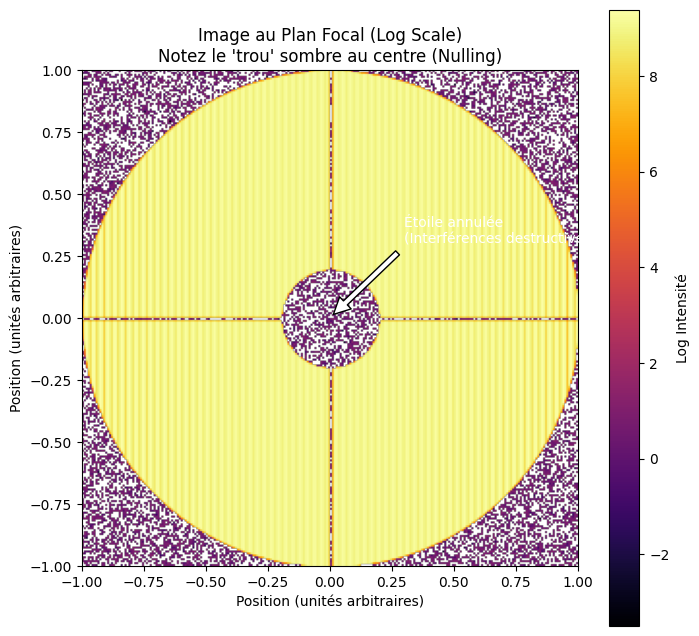

In [9]:
# Propagation vers le plan focal (Caméra)
camera = helios.Camera(pixels=(256, 256))
image = camera.process(wf_nulled, ctx)

# Visualisation
plt.figure(figsize=(8, 8))
# Échelle logarithmique pour mieux voir la dynamique
plt.imshow(np.log10(image + 1e-10), cmap='inferno', extent=[-1, 1, -1, 1])
plt.title("Image au Plan Focal (Log Scale)\nNotez le 'trou' sombre au centre (Nulling)")
plt.xlabel("Position (unités arbitraires)")
plt.ylabel("Position (unités arbitraires)")
plt.colorbar(label="Log Intensité")

# Annotation pour aider à comprendre
plt.annotate('Étoile annulée\n(Interférences destructives)', xy=(0, 0), xytext=(0.3, 0.3),
             arrowprops=dict(facecolor='white', shrink=0.05), color='white')

plt.show()